<h6><center></center></h6>

<h1>
<hr style=" border:none; height:3px;">
<center>Examen : Programmation statistique automatisée</center>
<hr style=" border:none; height:3px;">
</h1>

In [ ]:
import pandas as pd

Toute commande, même incomplète ou renvoyant une erreur sera prise en compte.

Commandes évaluées dans cet examen :    
**Exercice n°1**
- `read_csv()`
- `iloc` et `loc`
- `head()`
- `drop()`
- `columns`
- `dtypes`
- `astype()`
- `str`
- `==`, `&` et `|`
- `unique()`
- `nunique()`
- `sum()`
- `round()`
- `value_counts()`
- `sort_values()`
- `drop_duplicates()`
- `set_index()`
- `concat()`
- `corr()`  

**Exercice n°2 (Bonus)**
- `shape`
- `rename()`
- `dropna()`
- `isna()`
- `max()`
- `>` et `<`
- `quantile()`
- `reset_index()`


## 1. Censure des livres aux États-Unis

La documentation du jeu de données `book_banning.csv` est disponible à cette url : https://vincentarelbundock.github.io/Rdatasets/doc/bayesrules/book_banning.html.


Informations sur les États des États-Unis : https://fr.wikipedia.org/wiki/%C3%89tats_des_%C3%89tats-Unis.

1. Stockez le jeu de données `book_banning.csv` dans la variable `censure` et affichez les deux premières lignes de deux façons différentes.

In [ ]:
censure = pd.read_csv('book_banning.csv',sep=',')

In [ ]:
censure.head(2)

,rownames,title,book_id,author,date,year,removed,explicit,antifamily,occult,language,lgbtq,violent,state,political_value_index,median_income,hs_grad_rate,college_grad_rate
0,1,"House of the Spirits, The",927,"Allende, Isabel",2005-04-01,2005.0,0,1,0,1,1,1,1,AK,-13.4,15707.5,8.738042,0.67627
1,2,"It's Not the Stork!: A Book About Girls, Boys...",1024,"Harris, Robie",2008-02-06,2008.0,1,0,0,0,0,0,0,AK,-13.4,15707.5,8.738042,0.67627


In [ ]:
censure.iloc[:2,:]

,rownames,title,book_id,author,date,year,removed,explicit,antifamily,occult,language,lgbtq,violent,state,political_value_index,median_income,hs_grad_rate,college_grad_rate
0,1,"House of the Spirits, The",927,"Allende, Isabel",2005-04-01,2005.0,0,1,0,1,1,1,1,AK,-13.4,15707.5,8.738042,0.67627
1,2,"It's Not the Stork!: A Book About Girls, Boys...",1024,"Harris, Robie",2008-02-06,2008.0,1,0,0,0,0,0,0,AK,-13.4,15707.5,8.738042,0.67627


2. Supprimez la colonne `rownames`, qui n'est d'aucune utilité, et affichez le nom des colonnes.

In [ ]:
censure = censure.drop(columns="rownames")
print(censure.columns)

Index(['title', 'book_id', 'author', 'date', 'year', 'removed', 'explicit',
       'antifamily', 'occult', 'language', 'lgbtq', 'violent', 'state',
       'political_value_index', 'median_income', 'hs_grad_rate',
       'college_grad_rate'],
      dtype='object')


3. À quelle catégorie appartient chaque variable ? Les types sont-ils bien choisis ? Modifiez le type des colonnes si besoin (dans ce cas, utilisez les types spécifique à Pandas : `string`, `Int64`, `Float64`, `boolean`).

**Variables quantitatives continues** : `political_value_index`, `median_income`, `hs_grad_rate`, `college_grad_rate`    
**Variables quantitatives discrètes** : `year`     
**Variables qualitatives nominales** : `title`, `book_id`, `author`, `removed`, `explicit`, `antifamily`, `occult`, `language`, `lgbtq`, `violent`, `state`   
**Variable qualitative ordinale** : `date`    


In [ ]:
censure.dtypes

,0
title,object
book_id,int64
author,object
date,object
year,float64
removed,int64
explicit,int64
antifamily,int64
occult,int64
language,int64


Les types ne sont pas adaptés pour certaines des variables :
* `title`, `author` et `state` sont de type **`object`**. `object` est un type fourre-tout, il est recommandé d'utiliser un type plus spécifique pour les variables concernées lorsque c'est possible. Ici, le type `string` est le type le plus adapté.
* `date` est aussi de type **`object`**. Puisque cette variable contient des dates, le type `datetime` de Pandas est adapté. Le type `string` peut aussi convenir en fonction de l'utilisation prévue.
* `year` est une variable quantitative **discrète**, le type `float64` n'est pas adapté. Le type `Int64` serait plus adéquate.
* Les variables `removed`, `explicit`, `antifamily`, `occult`, `language`, `lgbtq`, `violent` sont des variables qualitatives nominales **binaires** : elles ne prennent que deux valeurs, 0 ou 1. Puisque ces variables indiquent si un livre est concerné ou non par chacun des motifs de censure, le type `boolean` serait plus adapté.

In [ ]:
censure[['title','author','date','state']] = censure[['title','author','date','state']].astype('string')
censure['year'] = censure['year'].astype('Int64')
censure[['removed','explicit','antifamily','occult','language','lgbtq','violent']] = censure[['removed','explicit','antifamily','occult','language','lgbtq','violent']].astype('boolean')

In [ ]:
censure.dtypes

,0
title,string[python]
book_id,int64
author,string[python]
date,string[python]
year,Int64
removed,boolean
explicit,boolean
antifamily,boolean
occult,boolean
language,boolean


4. D'après la documentation et éventuellement des ressources extérieures, que contient le jeu de données ? Contextualisez les données.

* **Quoi** : Ce jeu de données recense les demandes d'interdiction de livres aux États-Unis entre 2000 et 2010, couplées à des informations sur les États concernés. Une ligne correspond à la contestation d'un livre, dans un État, à une date donnée.
* **Qui** :
   - Données de contestation produites par : American Library Association (ALA)
> L'ALA compile des données sur les contestations de livres à partir de rapports soumis par les professionnels des bibliothèques sur le terrain ainsi que des articles de presse publiés à travers les États-Unis.
   - Données démographiques produites par : US Census Bureau
   - Données Political Value Index (PIV) produites par : Cook Political Report
> Le Cook Political Report est une lettre d'information indépendante et non partisane qui analyse les élections et les campagnes pour la Chambre des représentants et le Sénat des États-Unis, les postes de gouverneurs et la présidence, ainsi que les tendances politiques américaines.
   - Jeu de données final créé par : Shannon Fast et Thomas Hegland dans le cadre d'un projet universitaire au St Olaf College
* **Quand** : Années 2000 à 2010.
* **Où** : États-Unis hors Texas.
* **Comment** : Assemblage de trois jeux de données dans le cadre d'un projet universitaire.
* **Pourquoi** : Projet universitaire.
> De nombreuses études se sont penchées sur les raisons invoquées par ceux qui contestent un livre, mais peu ont examiné le contexte global dans lequel les interdictions surviennent — par exemple, les caractéristiques des États où elles se produisent. [source](https://bookdown.org/roback/bookdown-BeyondMLR/ch-GLMM.html)

5. Que peut-on dire concernant la qualité *a priori* de ce jeu de données ?

* **Sources fiables** : Gouvernement, organismes spécialisés, projet universitaire.
* **Fiabilité des données élevée** étant donné la fiabilité des sources.
* **Résolution spatiale limitée** : États.
* **Étendue spatiale limitée** : Exclusion du Texas.
* **Échelle temporelle limitée** : Les données ne couvrent que les années 2000 à 2010.
* **Ancienneté des données** : Les données les plus récentes remontent à 15 ans.

L'exclusion du Texas, le pays ayant enregistré le plus de contestations sur la période, est particulièrement problématique si l'objectif est de réaliser des statistiques descriptives. Si l'on souhaite par exemple connaître le motif de censure le plus fréquent ou l'évolution des motifs de censure au cours du temps aux État-Unis, utiliser cette base de données telle quelle fausserait l'analyse.

6. Le DataFrame possède une colonne `date` et une colonne `year`. Vérifiez la cohérence des deux variables :
- À partir de la colone `date`, de la méthode `str` et d'un slicing, créez une colonne `year_check`
- Comparez les valeurs de la colonne `year_check` et de la colonne `year`. Y a-t-il des incohérence ? **Retournez `True` ou `False`**.
- Si oui, affichez et commentez les incohérences, si non, passez à l'étape suivante.
- Supprimez la colonne `year_check`

In [ ]:
censure['year_check'] = censure['date'].str[:4]
# OU si vous avez converti `date` en datetime à la question précédente :
# - censure['date'].astype('string').str[:4]
# - OU censure['date'].dt.year
censure['year_check'] = censure['year_check'].astype('Int64')
# attention : `year` et `year_check` doivent être de même type pour la comparaison !
print("Y a-t-il des incohérences internes au jeu de données, entre la colonne `year` et la colonne `date` ?", (censure['year_check'] != censure['year']).any())
censure = censure.drop(columns='year_check')

Y a-t-il des incohérences internes au jeu de données, entre la colonne `year` et la colonne `date` ? False


Les deux variables, `date` et `year`, sont cohérentes.

7. Affichez les valeurs uniques pour la colonne `state`. Quels sont les États des États-Unis absents de ce jeu de données ? Comment expliquez-vous cette absence ?

In [ ]:
censure["state"].unique()

<StringArray>
['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DE', 'FL', 'GA', 'IA', 'ID', 'IL',
 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC',
 'ND', 'NE', 'NH', 'NJ', 'NM', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD',
 'TN', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']
Length: 47, dtype: string

In [ ]:
# Vous pouviez vous contenter de chercher l'information dans la page Wikipédia

usa_states = ['AL', 'AK', 'AZ', 'AR', 'CA', 'NC', 'SC', 'CO',
              'CT', 'ND', 'SD', 'DE', 'FL', 'GA', 'HI', 'ID',
              'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD',
              'MA', 'MI', 'MN', 'MS', 'MO', 'MT', 'NE', 'NV',
              'NH', 'NJ', 'NY', 'NM', 'OH', 'OK', 'OR', 'PA',
              'RI', 'TN', 'TX', 'UT', 'VT', 'VA', 'WV', 'WA',
              'WI', 'WY']

missing_states = list(set(usa_states) - set(censure["state"].unique()))

print(f"Les états {missing_states} sont absents du jeu de données.")
# NV : Nevada
# TX : Texas
# HI : Hawaï

Les états ['NV', 'HI', 'TX'] sont absents du jeu de données.


Pour le Texas, la documentation indique :
> Due to an outlying large number of challenges, book challenges made in the state of Texas were omitted.               

Une autre [source](https://bookdown.org/roback/bookdown-BeyondMLR/ch-GLMM.html#ref-Fast2011) nous apprend que le Texas a enregistré 683 contestations entre 2000 et 2010, soit près de cinq fois plus que l'État suivant dans le classement. Les contestations provenant du Texas ont probablement été retirées pour limiter le déséquilibre entre États.

Concernant le Nevada et le Texas, il n'y a probablement pas eu de demandes d'interdiction de livres dans ces États entre 2000 et 2010.

8. Affichez **le nombre** de valeurs uniques pour la colonne `book_id` et pour la colonne `title`. Comment expliqueriez-vous l'écart entre les deux valeurs ?

In [ ]:
print("Nombre de valeurs uniques pour `book_id` :", censure['book_id'].nunique())
print("Nombre de valeurs uniques pour `title` :", censure['title'].nunique())

Nombre de valeurs uniques pour `book_id` : 694
Nombre de valeurs uniques pour `title` : 724


Il y a plus de valeurs uniques pour le titre des livres que pour les identifiants. Certains livres sont donc probablement enregistrés dans la base de données sous plusieurs noms (disparité de format). `book_id` serait donc plus fiable pour identifier de façon unique chacun des livres.

9. Affichez l'identifiant et le titre des livres associés à l'autrice `Rowling, J.K.`. Qu'en pensez-vous ? Cela confirme-t-il l'hypothèse que vous avez émise à la question précédente ?

In [ ]:
censure.loc[censure['author'] == 'Rowling, J.K.',['book_id','title']]

,book_id,title
20,868,Harry Potter (series)
175,868,Harry Potter (series)
289,868,Harry Potter (series)
356,868,Harry Potter (series)
380,868,Harry Potter and the Chamber of Secrets
381,868,Harry Potter and the Prisoner of Azkaban
382,868,Harry Potter and the Sorcerer's Stone
390,868,Harry Potter (series)
391,868,Harry Potter (series)
393,868,Harry Potter and the Prisoner of Azkaban


L'identifiant 868 semble regrouper tous les livres de la saga Harry Potter. Ce cas est différent de l'hypothèse envisagée à la question précédente. Il ne s'agit pas d'une erreur ou d'un problème de qualité des données : plusieurs titres sont associés à l'identifiant 868, mais ces titres ne sont pas des variantes désignant un même objet (par exemple titre complet vs. titre partiel, erreurs de frappe, différence de casse (miniscule / majuscule), titre en plusieurs langues etc.), ils font référence à différent objets regroupés sous un même concept (référence à la saga entière vs. référence à un livre spécifique de la saga).

10. Affichez **en une seule commande** l'identifiant, le titre et l'auteur du livre situé à la **ligne de label 79** et du livre situé à la **ligne de label 515**.

   Que constatez-vous ? En quoi est-ce problématique ?
   
   Quelle conclusion tirez-vous des observations faites aux questions 3, 4 et 5 concernant le traitement à appliquer aux données ?

In [ ]:
censure.loc[[79,515],["book_id","title","author"]]

,book_id,title,author
79,1063,Just Friends,"Klein, Norma"
515,1063,Nothing's Sacred,"Black, Lewis"


Une recherche internet permet de confirmer que ces deux livres sont bels et bien des livres différents, qui n'ont aucun lien entre eux contrairement au cas précédent. Des livres différents peuvent donc être associés au même identifiant. Il s'agit d'un problème de qualité des données. Toute statistique calculée à partir de l'identifiant pourra s'en trouver faussée : si l'on cherche, par exemple, à identifier le livre qui a fait l'objet du plus grand nombre de demandes de censure, le livre intitulé "Just Friends" de Norma Klein gonflera erronément le total obtenu pour le livre "Nothing's Sacred" de Lewis Black, et inversement.

Nous pourrions identifier tous les cas pour lesquels un identifiant est associé à plusieurs titre, puis les vérifier un par un et les corriger si nécessaire.

11. Affichez dans **un seul** DataFrame l'identifiant, le titre et les auteurs :
- de tous les livres dont **l'identifiant est 46** et dont **le titre est `A Separate Reality`**
- de tous les livres dont **l'identifiant est 993** et dont **le titre est `My Brother Sam is Dead	`**

  Que remarquez-vous ?

  Nous allons corriger le problème pour l'un des livres concernés : remplacez par la **valeur correcte** les valeurs contenues dans la **colonne `author`** pour tous les livres dont **l'identifiant est 46** et dont **le titre est `A Separate Reality`**.

In [ ]:
# Affichez les lignes et les colonnes demandées

censure.loc[((censure.book_id==993) & (censure.title=="My Brother Sam is Dead")) |\
            ((censure.book_id==46) & (censure.title=="A Separate Reality")),["book_id","title","author"]]

,book_id,title,author
209,993,My Brother Sam is Dead,"Collier, James Lincoln"
465,993,My Brother Sam is Dead,"Collier, James Lincoln and Christopher Collier"
630,46,A Separate Reality,"Castaneda, Carlos"
659,46,A Separate Reality,"Casteneda, Carlos"


Il existe des disparités de format parmi les valeurs de la colonne `author` :
- pour "My Brother Sam is Dead", l'un des auteurs du livre est oublié pour la ligne de label 209 (Christopher Collier)
- pour "A Separate Reality", il y a une coquille dans le nom de l'auteur pour la ligne de label 659

In [ ]:
print("* Avant")
print(censure.loc[(censure.book_id==46) & (censure.title=="A Separate Reality"),["book_id","title","author"]])
print()

* Avant
     book_id               title             author
630       46  A Separate Reality  Castaneda, Carlos
659       46  A Separate Reality  Casteneda, Carlos



In [ ]:
# Corrigez les valeurs demandées dans la colonne `author`

# Sélection des lignes concernées et affectation de la bonne valeur
# Le nom d'auteur correct est Carlos Cast_a_neda

censure.loc[(censure.book_id==46) & (censure.title=="A Separate Reality"),"author"] = "Castaneda, Carlos"

In [ ]:
print("* Après")
print(censure.loc[(censure.book_id==46) & (censure.title=="A Separate Reality"),["book_id","title","author"]])

* Après
     book_id               title             author
630       46  A Separate Reality  Castaneda, Carlos
659       46  A Separate Reality  Castaneda, Carlos


12. Calculez le pourcentage de livres contestés qui ont effectivement été interdits. Arrondir à 2 chiffres après la virgule.

In [ ]:
print(f"{((censure.removed.sum() / len(censure))*100).round(2)}% des livres contestés ont abouti à une interdiction.")

23.31% des livres contestés ont abouti à une interdiction.


13. Quel est le livre (`book_id`) ayant été le plus contesté entre 2000 et 2010 ?

   Pour répondre à la question :
- Créez un DataFrame contenant le nombre de fois où chacune des valeurs uniques de la colonne `book_id` apparaît dans le jeu de données.
- Affichez uniquement la première ligne du DataFrame (qui doit correspondre au livre qui apparaît le plus grand nombre de fois dans le jeu de données).

**Bonus** :
- Quels sont les motifs invoqués ? Est-ce cohérent avec le sujet du livre ?

In [ ]:
censure["book_id"].value_counts().head(1)

,count
book_id,
143,17


In [ ]:
# non demandé
print("Le livre le plus contesté est :")
print(censure.loc[censure["book_id"] == 143, ["title","author"]].drop_duplicates().values.tolist())

Le livre le plus contesté est :
[['And Tango Makes Three', 'Parnell, Peter and Justin Richardson'], ['And Tango Makes Three', 'Parnell, Peter and Justin Richardsonter Parnell']]


**Remarque** : Notez qu'en réalité ce livre n'est peut-être pas le plus contesté sur la période étudiée puisqu'il nous manque les données du Texas !

In [ ]:
censure.loc[censure["book_id"] == 143, ["explicit","antifamily","occult","language", "lgbtq","violent"]].sum(axis=0)

,0
explicit,0
antifamily,5
occult,0
language,0
lgbtq,17
violent,0


"And Mango Makes Three" de Peter Parnell et Justin Richardson est un livre pour enfant qui raconte l'histoire d'un couple de pingouins mâles qui fonde une famille. Les motifs invoqués : contenu "LGBTQ" et contenu "anti-famille", sont cohérents.

14. Quel est le motif de censure le plus fréquent ?

   Pour répondre à la question :
- Créez un DataFrame contenant le nombre de fois où chaque motif a été invoqué. **Indice** : utilisez `sum()`.
- Triez le DataFrame par ordre décroissant.

In [ ]:
censure[["explicit","antifamily","occult","language", "lgbtq","violent"]].sum(axis=0).sort_values(ascending=False)

,0
explicit,299
language,237
violent,134
lgbtq,89
antifamily,40
occult,36


Le motif le plus fréquent est la présence de contenu sexuellement explicite dans le livre.

15. Les questions suivantes visent à évaluer s'il y a un lien entre le nombre de demandes de censure et les tendances politiques des États (plutôt Républicain (droite), Démocrate (gauche), ou neutre).

- Créez un DataFrame `states_challenge` contenant le nombre de fois où chacune des valeurs uniques de la colonne `state` apparaît dans le jeu de données.

In [ ]:
states_challenge = censure["state"].value_counts()

- Créez un DataFrame `states_political` ne contenant que les colonnes `state` et `political_value_index`, et supprimez les lignes dupliquées. Affichez le nombre de lignes avant et après déduplication.

In [ ]:
print("Nb lignes avant : ", len(censure))
states_political = censure[["state","political_value_index"]].drop_duplicates()
print("Nb lignes après : ", len(states_political))

Nb lignes avant :  931
Nb lignes après :  47


- Modifiez `status_political` pour que la colonne `state` devienne l'index du DataFrame.

In [ ]:
states_political = states_political.set_index("state")

- Concaténez `states_political` et `states_challenge` de façon à créer un DataFrame `states` contenant les colonnes des deux DataFrames.

In [ ]:
states = pd.concat([states_challenge,states_political], axis=1)
states.head()

,count,political_value_index
state,,
PA,148,2.0
OR,118,4.0
CO,81,-0.2
CA,50,7.4
IL,39,7.7


- Calculez la corrélation entre la colonne contenant le nombre de demandes de censure et la colonne `political_value_index`. Exprimez en mots ce que signifie cette corrélation ou cette absence de corrélation. Étant donné les motifs de censure considérés, le résultat vous surprend-il ?

  Corrélation n'est pas causalité, d'autres variables peuvent parfois expliquer une corrélation (facteurs de confusion). Voyez-vous ce qui pourrait expliquer un nombre élevé de demandes d'interdiction dans un État, en dehors de la sensibilité politique ?

In [ ]:
states.corr()

,count,political_value_index
count,1.000000,0.219956
political_value_index,0.219956,1.000000


Il semble y avoir une légère corrélation positive entre `political_value_index` et `count` : plus la valeur de `political_value_index` est élevée, donc plus un état est Démocrate (gauche américaine), plus le nombre de demande de censure est élevé.

Ce résultat peut surprendre car 3 des 6 motifs invoqués pour la censure correspondent d'avantage à des préoccupations conservatrices : contenu LGBTQ, contenu "anti-famille" et occultisme. Cependant, nous avons vu à la question 14 que ces motifs n'étaient pas les plus fréquents dans le jeu de données, ce ne sont donc pas eux qui influencent le plus le coefficient de corrélation.

La population des États pourrait en partie expliquer le nombre de demandes de censure : plus il y a d'habitants dans un État, plus il y a de lecteurs potentiels, donc plus il y a de personnes susceptibles de contester un livre. Il faudrait donc prendre en compte la population des États, en calculant, par exemple, la corrélation entre le nombre de censures **par million d'habitants** et l'index de sensibilité politique.

En triant le tableau de la page Wikipédia par nombre d'habitants, on observe que 4 des 6 premiers États ayant comptabilisés le plus grand nombre de demandes de censure (Texas inclus) sont parmis les 10 États les plus peuplés des Etats-Unis, ce qui semble appuyer l'hypothèse. Le Colorado et l'Oregon, respectivement 21ème et 27ème États les plus peuplés en 2024, font figure d'exception. Le Colorado est dit de tradition Républicaine tandis que l'Oregon est plutôt Démocrate, ce qui ne permet pas de déceler un éventuel lien entre sensibilité politique et nombre de demandes de censure. Il faudrait enrichir le jeu de données par le nombre d'habitants par État pour approfondir l'analyse.

* Nombre de demandes de censure : Texas > Pennsylvanie > Oregon > Colorado > Californie > Illinois
* Nombre d'habitants : Californie (1e) > Texas (2e) > Pennsylvanie (5e) > Illinois (6e) > Colorado (21e) > Oregon (27e)



## 2. Observations d'oiseaux (Bonus)

Observations d'oiseaux dans la région du Grand-Est entre 2018 et 2022.

Ces données proviennent de GBIF. Vous trouverez de la documentation à cette url : https://techdocs.gbif.org/en/data-use/download-formats, section "Simple download – Term definitions". N'hésitez pas à utiliser ctrl + F pour trouver rapidement un mot dans une page.

1. Stockez le jeu de données `oiseaux.csv` dans la variable `oiseaux` et affichez le nombre de lignes et de colonnes.

In [ ]:
oiseaux = pd.read_csv('oiseaux.csv',sep='\t')
oiseaux.shape

(1562597, 8)

2. Renommez la colonne `species` `birdSpecies` pour que tout utilisateur comprenne immédiatement ce que contient le jeu de données.

In [ ]:
oiseaux = oiseaux.rename(columns={"species":"birdSpecies"})
oiseaux.columns

Index(['decimalLatitude', 'decimalLongitude', 'birdSpecies', 'individualCount',
       'eventDate', 'day', 'month', 'year'],
      dtype='object')

2. Supprimez les lignes pour lesquelles le nom de l'espèce observée n'est pas connu. Sans le nom de l'espèce, ces observations sont inutilisables.

In [ ]:
print("Nb de lignes avant : ", len(oiseaux))
oiseaux = oiseaux.dropna(subset="birdSpecies")
print("Nb de lignes après : ", len(oiseaux))

Nb de lignes avant :  1562597
Nb de lignes après :  1558033


3. Combien de lignes ont des valeurs manquantes dans la colonne `eventDate` ? Combien de lignes ont des valeurs manquantes dans la colonne `month` ?

In [ ]:
print(f"Il y a {oiseaux.eventDate.isna().sum()} valeurs manquantes dans la colonne `eventDate`")
print(f"Il y a {oiseaux.month.isna().sum()} valeurs manquantes dans la colonne `eventDate")

Il y a 0 valeurs manquantes dans la colonne `eventDate`
Il y a 24077 valeurs manquantes dans la colonne `eventDate


Il n'y a aucune valeur manquante pour `eventDate` tandis qu'il y a 24077 valeurs manquantes pour `month`.

4. Pour comprendre cette apparente contradiction entre le nombre de valeurs manquantes dans le champ `eventDate` et le nombre de valeurs manquantes dans le champ `month`, affichez les valeurs uniques de `eventDate` pour les lignes avec données manquantes dans la colonne `month`.

   D'après vous, comment expliquer l'absence de mois ?
  
   Complétez, confirmez ou infirmez votre hypothèse grâce à la documentation : https://techdocs.gbif.org/en/data-processing/temporal-interpretation.

In [ ]:
oiseaux.loc[oiseaux["month"].isna(),"eventDate"].unique()

array(['2019-01-01/2019-12-31', '2018-01-01/2018-12-31',
       '2020-01-01/2020-12-31', '2018', '2019', '2020',
       '2021-01-01T00:00Z/2021-12-31T00:00Z',
       '2022-01-01T00:00Z/2022-12-31T00:00Z', '2022', '2021',
       '2021-01-01/2021-08-31', '2021-07-01/2021-09-15',
       '2021-04-01/2021-06-30', '2021-01-01/2021-12-31',
       '2019-07-27/2019-08-03', '2018-03-15/2018-09-12',
       '2018-02-21/2018-04-06', '2020-04-24/2020-05-07',
       '2018-04-10/2018-05-31', '2018-10-03/2018-11-07',
       '2018-10-16/2018-11-06', '2018-09-11/2018-11-07',
       '2018-09-05/2018-11-13', '2018-02-20/2018-04-17',
       '2018-09-05/2018-11-07', '2018-03-16/2018-04-11',
       '2018-02-20/2018-04-11', '2018-03-16/2018-04-10',
       '2018-03-29/2018-04-05', '2018-09-05/2018-10-03',
       '2018-08-24/2018-11-13', '2018-10-09/2018-11-06',
       '2018-10-16/2018-11-13', '2018-02-28/2018-03-08',
       '2018-04-25/2018-06-07', '2018-04-19/2018-05-24',
       '2018-03-20/2018-04-11', '2018-

Le mois semble être absent lorsque la valeur dans `eventDate` est un interval de dates tel que le mois de la date de début et de la date de fin ne coïncident pas, ou lorsque seule l'année est connue.

Le tableau 1 de la page web confirme l'hypothèse.

5. À quelle catégorie appartiennent les valeurs manquantes de la colonne `month` ? Justifiez. Appliqueriez-vous un traitement à ces données manquantes ? Si oui, lequel et dans quelle situation, si non, pourquoi ?

In [ ]:
(100 * (oiseaux.month.isna().sum() / len(oiseaux))).round(2)

np.float64(1.55)

Ces valeurs manquantes sont de type MCAR car elles sont entièrement explicables par les valeurs contenues dans la colonne `eventDate`.

Les mois de début et de fin d'intervalle étant différents, compléter les valeurs manquantes ne paraît pas judicieux. Si une information mensuelle est absolument nécessaire pour l'analyse, les lignes concernées pourraient être supprimées puisqu'elles ne représentent que 1.55% des données (à moins que d'autres biais soient observés, par exemple une concentration de ces observations dans une zone géographique spécifique). On pourrait éventuellement décider de ne garder que la date de début ou de fin de l'intervalle, et compléter la colonne `month` en fonction, mais cela pourrait fausser l'analyse.

6. Exécutez la cellule ci-dessous, qui produit une boîte à moustache pour la variable `individualCount`. À quoi correspond la variable `individualCount` ? Que pensez-vous des valeurs qui se détachent sur le graphe ?

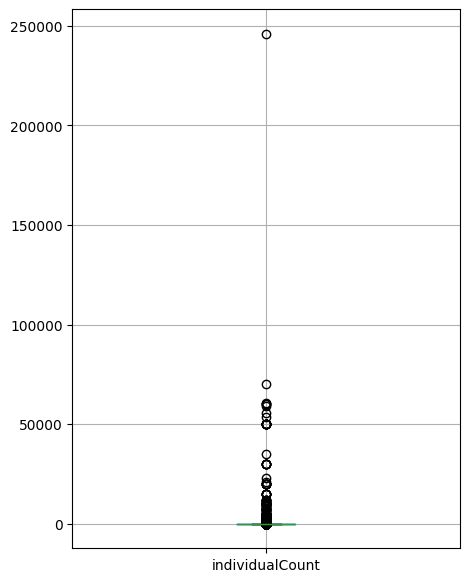

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5,7))
oiseaux.boxplot(column='individualCount')
plt.show()

`individualCount` correspond au nombre d'individus observés pour une espèce donnée, à un instant donné et à une localisation donnée. Les valeurs qui se détachent sur le graphe sont des valeurs aberrantes (_outlier_). Du point de vue d'un néophyte, ces valeurs semblent être des erreurs : est-il possible d'observer plusieurs dizaines de millier d'oiseaux d'un coup ? Le point proche de 250 000 est très certainement une erreur.

7. Récupérer les informations associées à la valeur maximale de `individualCount`.

   Faites quelques recherches sur l'espèce concernée. La valeur de `individualCount` vous paraît-elle plausible ? Justifiez et indiquez les liens des ressources sur lesquelles vous vous appuyez pour répondre.

In [ ]:
oiseaux[oiseaux.individualCount == oiseaux.individualCount.max()]

,decimalLatitude,decimalLongitude,birdSpecies,individualCount,eventDate,day,month,year
1130052,48.591595,4.706911,Grus grus,246000.0,2019-09-25,25.0,9.0,2019


La page [Wikipédia](https://fr.wikipedia.org/wiki/Grue_cendr%C3%A9e) indique :
> La population mondiale de grues cendrées adultes est estimée en 2021 à 482 000 individus.

Il semble donc a priori peu probable que plus de la moitié de la population mondiale de grues cendrées ait pu être observée simultanément en un lieu.

Cependant, la suite de l'article Wikipédia indique :
> La France est un important pays d'accueil pour les grues venant y faire une halte ou pour hiverner. Les principaux sites fréquentés sont le lac du Der qui détient le record absolu d'individus présents simultanément (nombre estimé à 268 120 par les compteurs bénévoles de la LPO).

La LPO étant une source fiable, il semblerait donc que, aussi surprenant que cela puisse paraître, la valeur renseignée dans `individualCount` ne soit pas une erreur !

8. Filtrez les observations associées à une valeur plus grande que 1000 pour `individualCount`.

   Comptez le nombre de fois où chaque espèce de ce sous-ensemble apparaît dans ce sous-ensemble.

   Faites des recherches sur quelques uns des oiseaux. Remarquez-vous des points communs qui pourraient expliquer les valeurs de `individualCount` ?

In [ ]:
oiseaux.loc[oiseaux['individualCount'] > 1000,"birdSpecies"].value_counts()

,count
birdSpecies,
Grus grus,174
Anas crecca,52
Columba palumbus,37
Vanellus vanellus,28
Fulica atra,25
Sturnus vulgaris,24
Phalacrocorax carbo,22
Pluvialis apricaria,17
Aythya ferina,11


En consultant les articles Wikipédia des 10 premières espèces, nous pouvons constater que ces espèces sont toutes des espèces sociales voire grégaires, qui peuvent être observées en nombre, notamment pendant les périodes de migration.

### Bonus du bonus

9. Créez un DataFrame `oiseaux_count` comptant le nombre de fois où chaque espèce a été observée. Réinitialisez les indices aux indices par défaut.

In [ ]:
oiseaux_count = oiseaux['birdSpecies'].value_counts()

In [ ]:
oiseaux_count = oiseaux_count.reset_index()

11. Affichez les quantiles 0.25, 0.5 et 0.75 pour la variable contenant le nombre d'observations. Qu'en pensez-vous ?

In [ ]:
oiseaux_count['count'].quantile([0.25,0.5,0.75])

,count
0.25,5.5
0.50,171.0
0.75,2858.0


La plage de valeur est étendue. Il y a un déséquilibre entre les espèces.

12. Affichez les trois premières lignes de `oiseaux_count`. Affichez les trois dernières lignes. Affichez les lignes pour lesquelles le nombre d'observations est strictement supérieur à 10 et strictement inférieur à 30.

    En cherchant le nom des oiseaux dans la page Avibase (ctrl + F est votre ami) et en faisant des recherches internet si nécessaire, quel constat faites-vous concernant les oiseaux les moins représentés dans la base de données, les oiseaux peu représentés dans la base de données et les oiseaux les plus représentés dans la base de données ? Ces observations influenceraient-elles vos choix de traitement ?    

    Avibase : https://avibase.bsc-eoc.org/checklist.jsp?lang=EN&p2=1&list=clements&synlang=&region=FRge&version=text&lifelist=&highlight=0

In [ ]:
oiseaux_count.iloc[:3,:]

,birdSpecies,count
0,Parus major,69175
1,Turdus merula,63358
2,Fringilla coelebs,58621


Ces trois oiseaux apparaissent dans la checklist des oiseaux du Grand-Est, c'était attendu.

In [ ]:
oiseaux_count.iloc[-3:,:]

,birdSpecies,count
420,Grus canadensis,1
421,Histrionicus histrionicus,1
422,Eudromia elegans,1


Grus canadensis et Eudromia elegans n'apparaissent pas dans la checklist. Histrionicus histrionicus est indiqué comme ayant une origine incertaine. L'espèce Grus canadensis semble pouvoir être observée sur la côte Atlantique, mais très rarement, d'après [oiseaux.net](https://www.oiseaux.net/oiseaux/grue.du.canada.html). L'espèce Eudromia elegans ne vit qu'en Amérique du Sud d'après Wikipédia et [oiseaux.net](https://www.oiseaux.net/oiseaux/tinamou.elegant.html). D'après Wikipédia, Histrionicus histrionicus vit essentiellement en Amérique du Nord-Ouest et en Asie du Nord-Est.

Les espèces observées moins de 10 fois sont probablement des erreurs d'identification, ou en tout cas ne sont pas fiables.

In [ ]:
oiseaux_count[(oiseaux_count['count'] > 10) & (oiseaux_count['count'] < 30)]

,birdSpecies,count
267,Aythya collaris,29
268,Melanitta nigra,28
269,Elanus caeruleus,27
270,Alle alle,26
271,Clangula hyemalis,25
272,Rissa tridactyla,25
273,Hieraaetus pennatus,24
274,Prunella collaris,24
275,Glaucis hirsutus,24
276,Anser cygnoides,22


Melanitta nigra et Alle alle apparaissent dans la checklist comme deux des espèces présentes dans le Grand-Est. Les espèces Aythya collari et Elanus caeruleus sont notées comme **rares / accidentelles** dans la checklist. Clangula hyemalis et Rissa tridactyla sont des espèces **vulnérables** d'après la checklist, donc probablement plus difficiles à observer carcomptant peu d'individus. Anser cygnoides n'apparaît pas dans la checklist.

Ces observations ne semblent pas erronées.

Concernant le traitement, nous pourrions utiliser la checklist pour éliminer les observations douteuses.